In [1]:
from lsfb_dataset import LSFBIsolConfig, LSFBIsolLandmarks
from mediapipe.python.solutions.drawing_utils import plot_landmarks
from numba.np.polynomial.polynomial_functions import numpy_polyadd
from numpy.ma.core import maximum
from sympy.stats.sampling.sample_numpy import numpy

dataset = LSFBIsolLandmarks(LSFBIsolConfig(
    root="C:/Users/abassoma/Documents/Dataset/GSL",
    split="train",
    n_labels=310,
    sequence_max_length=50
))
features, target = dataset[0]

100%|██████████| 23315/23315 [00:35<00:00, 654.83it/s]


In [2]:
keys_distribution = {}
for signs in dataset:
    elem, _ = signs
    el = elem['pose'].shape[0]
    keys_distribution[el] = keys_distribution.get(el, 0) + 1
print(keys_distribution)

{11: 1326, 16: 1521, 10: 1101, 12: 1644, 13: 1701, 15: 1599, 17: 1465, 14: 1520, 18: 1314, 7: 497, 20: 1053, 8: 595, 9: 848, 31: 127, 25: 468, 24: 571, 30: 148, 19: 1216, 34: 62, 27: 289, 6: 327, 21: 869, 23: 619, 22: 734, 4: 97, 5: 159, 3: 36, 2: 6, 26: 329, 29: 185, 28: 235, 32: 94, 1: 2, 35: 65, 33: 73, 41: 16, 37: 25, 42: 15, 36: 67, 39: 29, 46: 19, 50: 122, 38: 27, 43: 16, 49: 8, 45: 13, 48: 6, 40: 23, 44: 23, 47: 11}


In [3]:
m,_ = dataset[58]
import numpy as np
print(m['left_hand'].shape)
l = m['left_hand']
r = m['right_hand']
p = m['pose']
print(l.shape, r.shape, p.shape)
sign = np.concatenate((l,r,p), axis=1)
print(sign.shape)
print(sign)

(8, 21, 2)
(8, 21, 2) (8, 21, 2) (8, 33, 2)
(8, 75, 2)
[[[0.6274 0.8696]
  [0.601  0.8926]
  [0.589  0.9287]
  ...
  [0.417  1.53  ]
  [0.5273 1.606 ]
  [0.419  1.59  ]]

 [[0.628  0.8726]
  [0.6016 0.893 ]
  [0.5894 0.9287]
  ...
  [0.4136 1.547 ]
  [0.524  1.62  ]
  [0.4185 1.6045]]

 [[0.6284 0.8755]
  [0.602  0.8936]
  [0.59   0.9287]
  ...
  [0.4111 1.559 ]
  [0.5215 1.631 ]
  [0.4182 1.615 ]]

 ...

 [[0.6294 0.881 ]
  [0.603  0.8936]
  [0.591  0.9272]
  ...
  [0.4097 1.564 ]
  [0.5195 1.639 ]
  [0.419  1.621 ]]

 [[0.6294 0.882 ]
  [0.603  0.8936]
  [0.591  0.927 ]
  ...
  [0.41   1.563 ]
  [0.5195 1.639 ]
  [0.4202 1.62  ]]

 [[0.6294 0.8823]
  [0.6035 0.8936]
  [0.591  0.9263]
  ...
  [0.4106 1.5625]
  [0.5195 1.636 ]
  [0.4219 1.619 ]]]


In [91]:
import torch
from torch.utils.data import DataLoader
train_loader = DataLoader(dataset=dataset, batch_size=32, shuffle=True)
x = next(iter(train_loader))

RuntimeError: stack expects each tensor to be equal size, but got [11, 33, 2] at entry 0 and [9, 33, 2] at entry 1

In [19]:
feature = [np.concatenate((elem['left_hand'], elem['right_hand']), axis=0) for elem, _ in dataset]
feature = [items.reshape(items.shape[:1] +(-1,)) for items in feature]
max_frame = max(frame.shape[0] for frame in feature)
print(max_frame)

100


<BarContainer object of 50 artists>

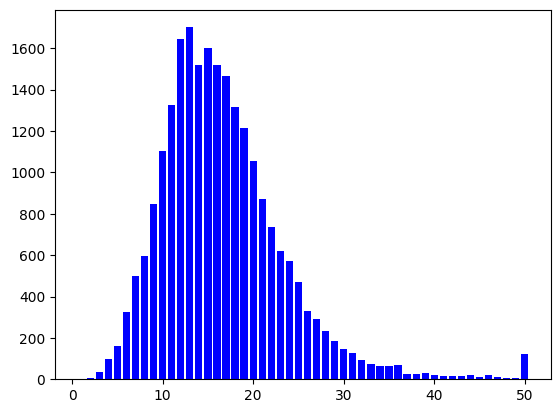

In [4]:
import matplotlib.pyplot as plt
plt.bar(keys_distribution.keys(), keys_distribution.values(), color='b')

16


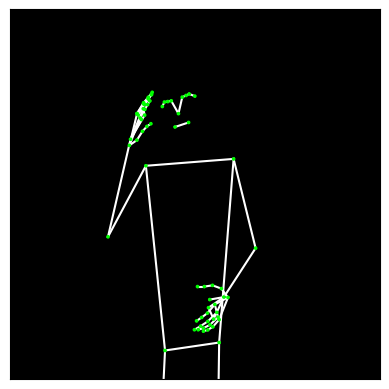

[[-0.0007324 -0.002197 ]
 [-0.0002441 -0.002075 ]
 [ 0.0002441 -0.002197 ]
 [ 0.0002441 -0.00232  ]
 [ 0.        -0.002075 ]
 [-0.0002441 -0.003052 ]
 [ 0.0007324 -0.00464  ]
 [ 0.001221  -0.0008545]
 [ 0.002441  -0.00415  ]
 [ 0.0002441 -0.001465 ]
 [ 0.        -0.002441 ]
 [ 0.001953   0.001465 ]
 [ 0.000977  -0.00537  ]
 [ 0.000977   0.000977 ]
 [-0.001953  -0.02637  ]
 [ 0.         0.000977 ]
 [ 0.001465  -0.06494  ]
 [ 0.0004883  0.001465 ]
 [ 0.01172   -0.0679   ]
 [ 0.000977   0.       ]
 [ 0.01099   -0.0637   ]
 [ 0.000977   0.       ]
 [ 0.006836  -0.0598   ]
 [ 0.        -0.001465 ]
 [ 0.001465  -0.000977 ]
 [ 0.001953  -0.003906 ]
 [ 0.005127  -0.001953 ]
 [ 0.003418  -0.004883 ]
 [ 0.005127  -0.003906 ]
 [ 0.003418  -0.003906 ]
 [ 0.004883  -0.00586  ]
 [ 0.004883  -0.006836 ]
 [ 0.004395  -0.00293  ]]


In [72]:
from sign_language_tools.visualization.plot.landmarks import *
from sign_language_tools.pose.mediapipe.edges import *
sign, _ = dataset[49]
print(sign['left_hand'].shape[0])
left_hand = sign['left_hand'][5]
right_hand = sign['right_hand'][5]
right_hand_next = sign['pose'][7]
pose = sign['pose'][5]
plot_landmarks(left_hand, HAND_EDGES)
plot_landmarks(right_hand, HAND_EDGES)
plot_landmarks(pose,POSE_EDGES)
plt.show()
diff = pose - right_hand_next
print(diff)

In [24]:
import torch
x = torch.randn(4, 10)
even_poss = x[:, ::2]
print(even_poss.index())

AttributeError: 'Tensor' object has no attribute 'index'

In [43]:
x = torch.randn(4, 20)
import math
even_poss =  torch.arange(0,20,2)
odd_poss =  torch.arange(1,20,2)
div_term = 10000 ** (even_poss/ 512)
even_p = torch.sin(even_poss / div_term)
print(even_p)

tensor([ 0.0000,  0.9364, -0.5486, -0.7815,  0.6008,  0.8778, -0.2429, -0.9937,
        -0.5380,  0.4392])


In [47]:
x = torch.randn(20)
x.expand(4,20)

tensor([[-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953],
        [-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953],
        [-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953],
        [-1.3218, -0.5651,  1.0596,  1.1139, -0.4558, -1.5486,  0.8054,  0.8231,
         -2.0709, -0.0200,  0.7626, -0.4170,  0.7623,  1.6054, -1.0754, -0.8413,
         -0.4914,  0.2493, -0.6195,  0.3953]])